In [7]:
import subprocess, tempfile, os
from pathlib import Path
from IPython.core.magic import register_cell_magic
from IPython.display import Image, display

BASE = Path.cwd()
GUILE_DIR = BASE / 'guile'

@register_cell_magic
def frac(line, cell):
    with tempfile.NamedTemporaryFile(mode='w', suffix='.frac', delete=False) as f:
        f.write(cell)
        path = f.name
    try:
        r = subprocess.run(
            ['guile', '--no-auto-compile', '-c',
             '(load "fractal-reader.scm") (run-frac-file "' + path + '")'],
            capture_output=True, text=True,
            cwd=str(GUILE_DIR), timeout=300
        )
        if r.stdout:
            print(r.stdout.strip())
        if r.returncode != 0:
            print('Erro Guile:\n', r.stderr[-600:])
            return
        for ln in reversed(cell.splitlines()):
            tok = ln.strip().split()
            if tok and tok[0] == 'generate':
                png = GUILE_DIR / (tok[1].lower() + '.png')
                if png.exists():
                    display(Image(str(png), width=700))
                break
    finally:
        os.unlink(path)

print('Magic %%frac pronto — rode as celulas abaixo.')


Magic %%frac pronto — rode as celulas abaixo.


# FractalDSL — ao vivo

Rode a **célula de setup** uma vez. Depois rode qualquer célula abaixo: o Guile processa o código `.frac`, gera os pontos, e o Python renderiza a imagem inline.

Cada célula é código `.frac` puro — a linguagem que construímos.


---
## 1. Mandelbrot

O fractal mais famoso. Para cada ponto `c` do plano complexo, itera `z = z² + c` partindo de `z = 0`.
A cor indica quantas iterações até `|z| > 2`. Pontos que nunca escapam ficam pretos — esse é o conjunto de Mandelbrot.


160,000 pontos carregados de mandelbrot.csv
  → salvo em mandelbrot.png
Compilando: Mandelbrot
(define Mandelbrot (let* ((f (create-fractal Mandelbrot)) (f (equation f z=z^2+c)) (f (iterations f 80)) (f (center f -0.5 0)) (f (zoom f 100)) (f (set-field f (quote resolution) (list 400 400)))) f))
Configurando render: ((width . 900) (height . 900) (color . fire) (style . island))
Exportando: mandelbrot.csv
Renderizando → mandelbrot.png
PNG gerado.


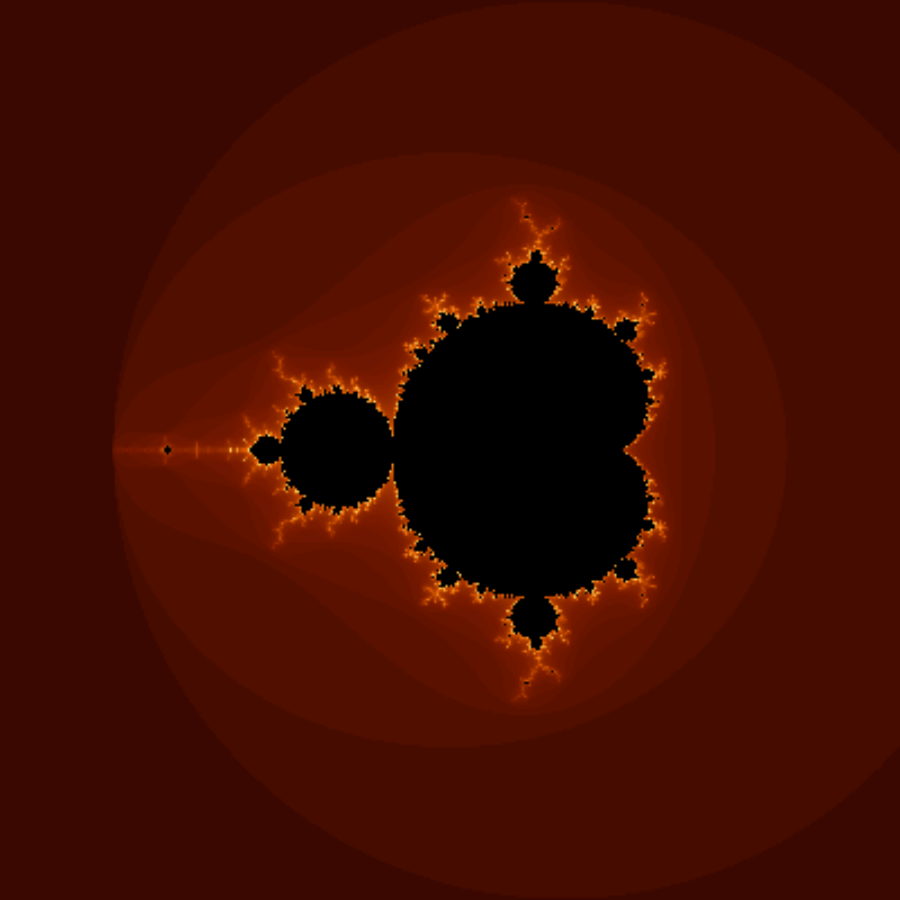

In [8]:
%%frac
fractal Mandelbrot
    equation   z=z^2+c
    iterations 80
    center     -0.5 0
    zoom       100
    resolution 400 400

render
    resolution 900 900
    color fire

generate Mandelbrot


---
## 2. Ilha

Coastline fractal: começa com um polígono de 7 vértices. A cada nível de `depth`, os pontos médios de cada aresta
são deslocados aleatoriamente por `roughness`. A decoração aplica um Barnsley Fern em escala reduzida
em cada ponto médio — gerando a 'vegetação' clipada ao interior.


36,208 pontos carregados de ilha.csv
    coast: 448 pts  |  decor: 35,760 pts
  → salvo em ilha.png
Compilando: Ilha
(define Ilha (let* ((f (create-fractal Ilha)) (f (set-field f (quote iterations) 10000)) (f (set-field f (quote coastline) (list (cons (quote points) 7) (cons (quote radius) 1.0) (cons (quote roughness) 0.4) (cons (quote depth) 6) (cons (quote decorate) (list (cons (quote steps) 80) (cons (quote scale) 0.06) (cons (quote transforms) (list (transform 0.85 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.85 (affine 0.85 0.04 -0.04 0.85 0.0 1.6))))) (transform 0.07 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.07 (affine 0.2 -0.26 0.23 0.22 0.0 1.6))))) (transform 0.07 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.07 (affine -0.15 0.28 0.26 0.24 0.0 0.44))))) (transform 0.01 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.01 (affine 0.0 0.0 0.0 0.16 0.0 0.0))))))))))))) f))
Configurando render: ((width . 1000) (heig

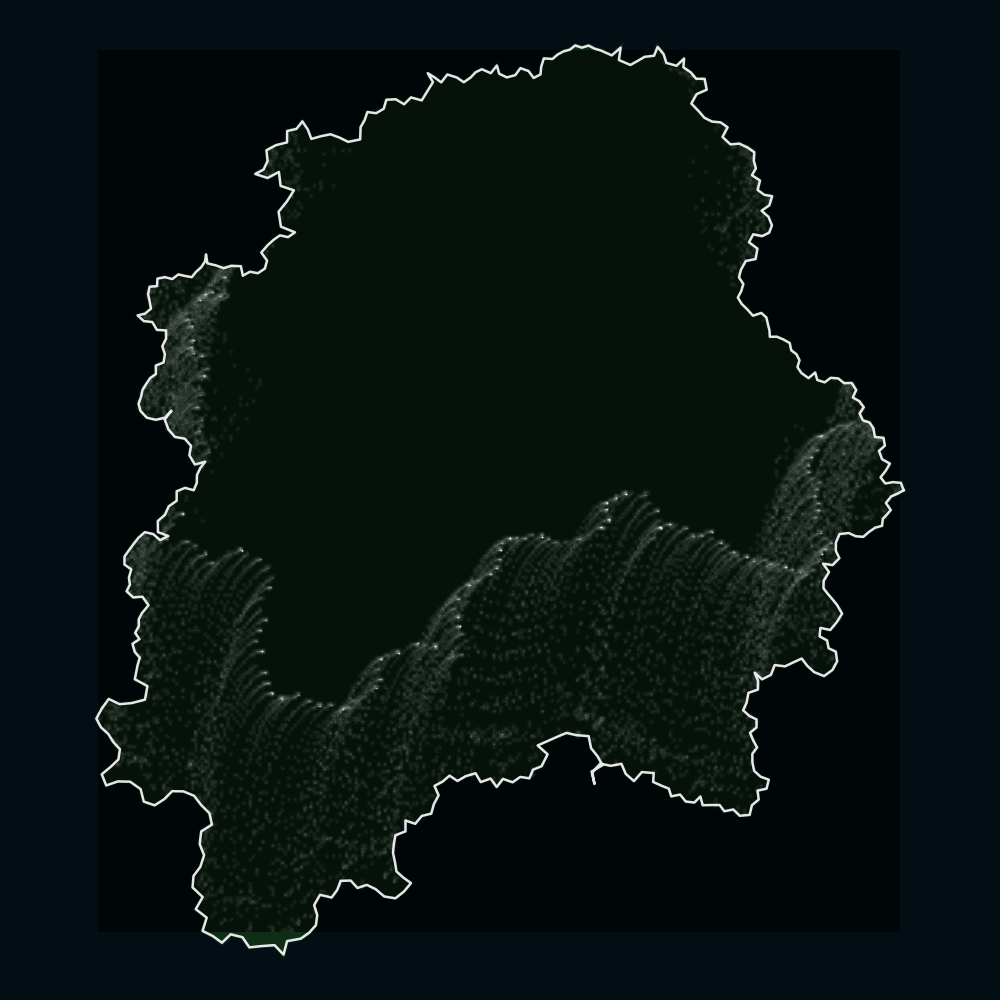

In [3]:
%%frac
fractal Ilha
    iterations 10000
    coastline
        points    7
        radius    1.0
        roughness 0.4
        depth     6
        decorate
            steps 80
            scale 0.06
            transform 0.85
                depth 4
                barnsley
                    affine 0.85  0.85  0.04 -0.04  0.85  0.0  1.60
            transform 0.07
                depth 4
                barnsley
                    affine 0.07  0.20 -0.26  0.23  0.22  0.0  1.60
            transform 0.07
                depth 4
                barnsley
                    affine 0.07 -0.15  0.28  0.26  0.24  0.0  0.44
            transform 0.01
                depth 4
                barnsley
                    affine 0.01  0.0   0.0   0.0   0.16  0.0  0.0

render
    resolution 1000 1000
    color mono
    style island

generate Ilha


---
## 3. Floresta

Mesma estrutura que a ilha, mas com `points 9` e `roughness 0.55` (costa mais recortada)
e `steps 120` (vegetação mais densa). O estilo `forest` preenche o interior em verde escuro.

Experimente mudar `roughness` entre `0.1` (suave) e `0.9` (muito irregular).


69,576 pontos carregados de floresta.csv
    coast: 576 pts  |  decor: 69,000 pts
  → salvo em floresta.png
Compilando: Floresta
(define Floresta (let* ((f (create-fractal Floresta)) (f (set-field f (quote iterations) 15000)) (f (set-field f (quote coastline) (list (cons (quote points) 9) (cons (quote radius) 1.0) (cons (quote roughness) 0.55) (cons (quote depth) 6) (cons (quote decorate) (list (cons (quote steps) 120) (cons (quote scale) 0.06) (cons (quote transforms) (list (transform 0.85 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.85 (affine 0.85 0.04 -0.04 0.85 0.0 1.6))))) (transform 0.07 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.07 (affine 0.2 -0.26 0.23 0.22 0.0 1.6))))) (transform 0.07 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.07 (affine -0.15 0.28 0.26 0.24 0.0 0.44))))) (transform 0.01 (with-depth 4 (ifs (create-fractal BarnsleyFern) (transform 0.01 (affine 0.0 0.0 0.0 0.16 0.0 0.0))))))))))))) f))
Configurando render:

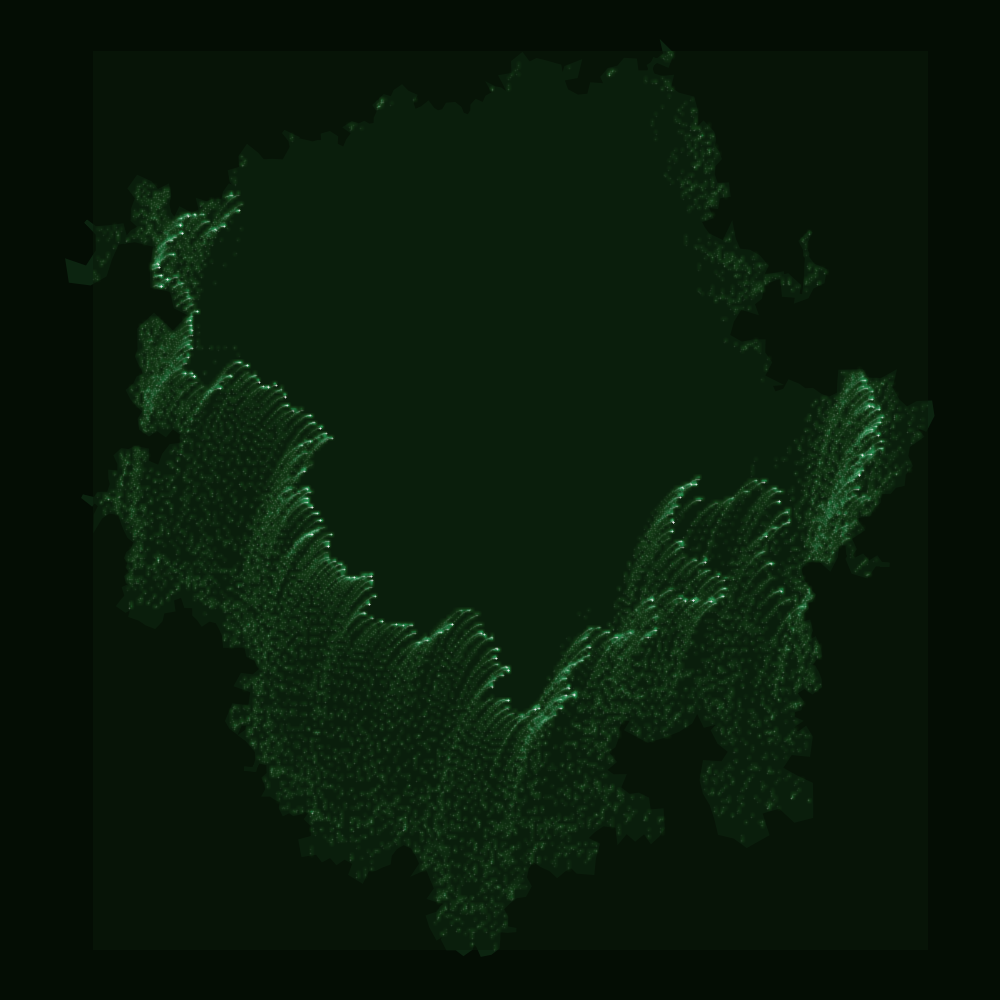

In [9]:
%%frac
fractal Floresta
    iterations 15000
    coastline
        points    9
        radius    1.0
        roughness 0.55
        depth     6
        decorate
            steps 120
            scale 0.06
            transform 0.85
                depth 4
                barnsley
                    affine 0.85  0.85  0.04 -0.04  0.85  0.0  1.60
            transform 0.07
                depth 4
                barnsley
                    affine 0.07  0.20 -0.26  0.23  0.22  0.0  1.60
            transform 0.07
                depth 4
                barnsley
                    affine 0.07 -0.15  0.28  0.26  0.24  0.0  0.44
            transform 0.01
                depth 4
                barnsley
                    affine 0.01  0.0   0.0   0.0   0.16  0.0  0.0

render
    resolution 1000 1000
    color green
    style forest

generate Floresta


---
## 4. Samambaia de Barnsley

IFS puro: 4 transformações afins com probabilidades (0.01, 0.85, 0.07, 0.07).
O jogo do caos escolhe uma a cada passo. Com 50.000 pontos, a forma da samambaia emerge
por auto-similaridade — nenhum desenho explícito, só matemática.

Tente aumentar `iterations` para `200000` e veja mais detalhe.


50,000 pontos carregados de barnsleyfern.csv
  → salvo em barnsleyfern.png
Compilando: BarnsleyFern
(define BarnsleyFern (let* ((f (create-fractal BarnsleyFern)) (f (set-field f (quote iterations) 50000)) (f (set-field f (quote ifs) (list (transform 0.01 (with-depth 1 (ifs (create-fractal BarnsleyFern) (transform 1.0 (affine 0.0 0.0 0.0 0.16 0.0 0.0))))) (transform 0.85 (with-depth 1 (ifs (create-fractal BarnsleyFern) (transform 1.0 (affine 0.85 0.04 -0.04 0.85 0.0 1.6))))) (transform 0.07 (with-depth 1 (ifs (create-fractal BarnsleyFern) (transform 1.0 (affine 0.2 -0.26 0.23 0.22 0.0 1.6))))) (transform 0.07 (with-depth 1 (ifs (create-fractal BarnsleyFern) (transform 1.0 (affine -0.15 0.28 0.26 0.24 0.0 0.44))))))))) f))
Configurando render: ((width . 700) (height . 900) (color . limegreen) (style . island))
Exportando: barnsleyfern.csv
Renderizando → barnsleyfern.png
PNG gerado.


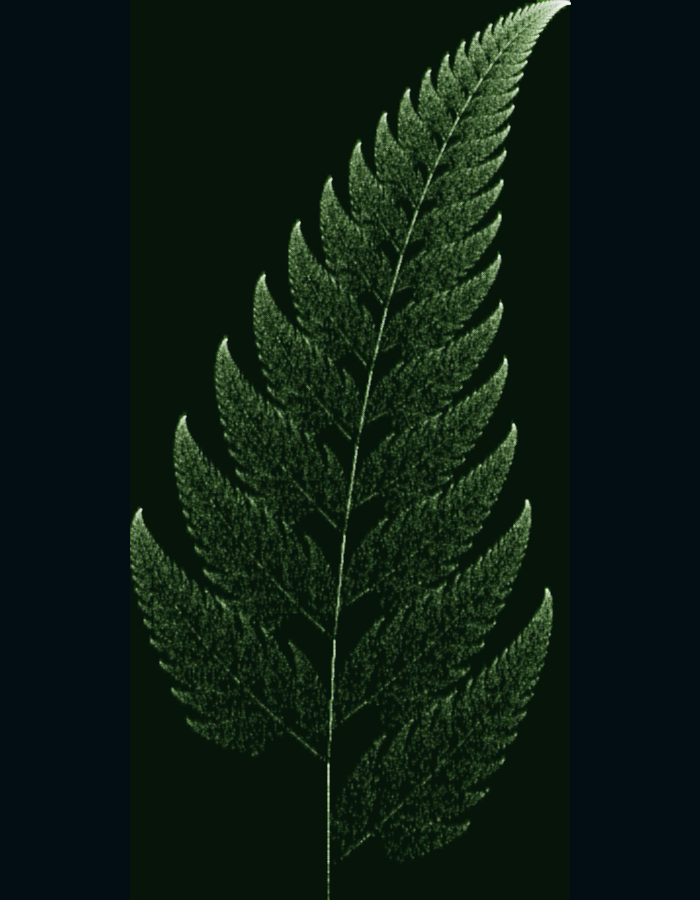

In [10]:
%%frac
fractal BarnsleyFern
    iterations 50000
    ifs
        transform 0.01
            depth 1
            barnsley
                affine 1.0  0.00  0.00  0.00  0.16  0.00  0.00
        transform 0.85
            depth 1
            barnsley
                affine 1.0  0.85  0.04 -0.04  0.85  0.00  1.60
        transform 0.07
            depth 1
            barnsley
                affine 1.0  0.20 -0.26  0.23  0.22  0.00  1.60
        transform 0.07
            depth 1
            barnsley
                affine 1.0 -0.15  0.28  0.26  0.24  0.00  0.44

render
    resolution 700 900
    color limegreen
    style island

generate BarnsleyFern


---
## 5. Mergulho no Mandelbrot

O mesmo fractal com `center -0.745 0.1` e `zoom 800` — o 'vale do caranguejo-ferradura'.
Mais `iterations` são necessárias para revelar detalhes na borda.
A auto-similaridade garante que cada zoom revela novas estruturas idênticas à escala anterior.


160,000 pontos carregados de mandelbrotzoom.csv
  → salvo em mandelbrotzoom.png
Compilando: MandelbrotZoom
(define MandelbrotZoom (let* ((f (create-fractal MandelbrotZoom)) (f (equation f z=z^2+c)) (f (iterations f 300)) (f (center f -0.745 0.1)) (f (zoom f 800)) (f (set-field f (quote resolution) (list 400 400)))) f))
Configurando render: ((width . 900) (height . 900) (color . ocean) (style . island))
Exportando: mandelbrotzoom.csv
Renderizando → mandelbrotzoom.png
PNG gerado.


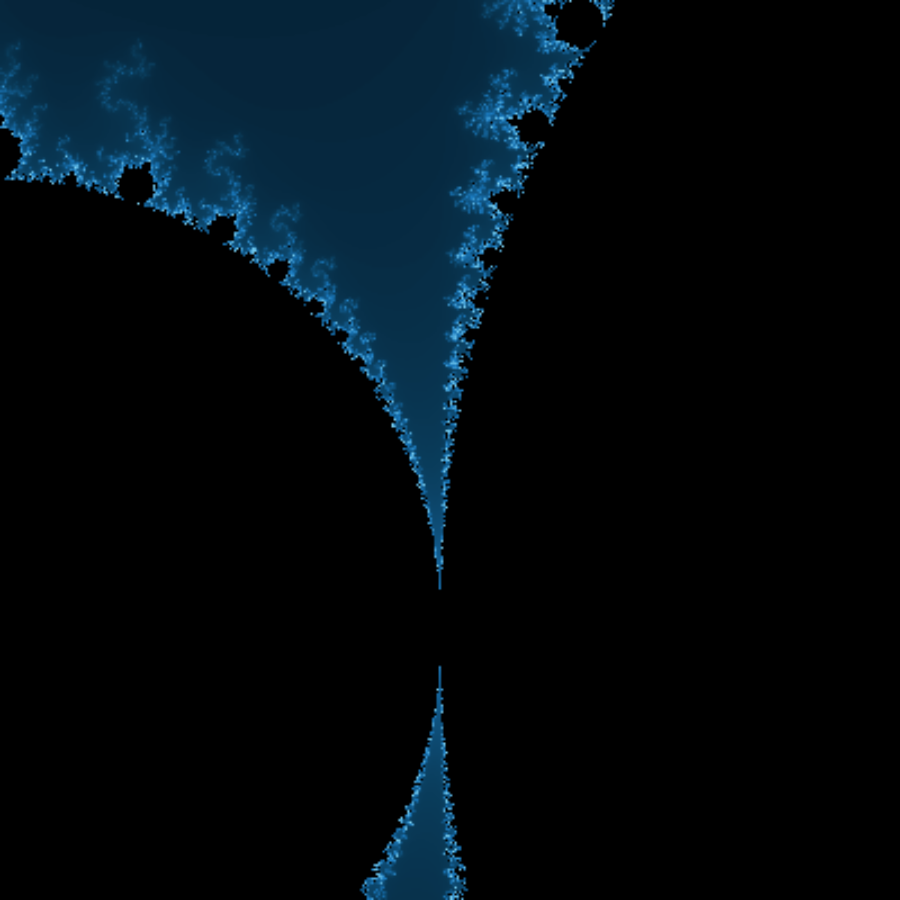

In [6]:
%%frac
fractal MandelbrotZoom
    equation   z=z^2+c
    iterations 300
    center     -0.745 0.1
    zoom       800
    resolution 400 400

render
    resolution 900 900
    color ocean

generate MandelbrotZoom


---
## Experimente

Cada parâmetro tem efeito visual imediato — edite e rode de novo:

| Parâmetro | O que muda |
|---|---|
| `roughness` | Quão recortada é a costa (0 = círculo, 1 = caos) |
| `depth` | Níveis de subdivisão da costa |
| `steps` | Densidade da vegetação |
| `iterations` | Mandelbrot: detalhe na borda; IFS: densidade de pontos |
| `zoom` | Zoom no plano complexo (Mandelbrot/Julia) |
| `center` | Centro da janela no plano complexo |
| `color` | `fire`, `ocean`, `teal`, `green`, `limegreen`, `mono`, `gradient` |
| `style` | `island`, `forest`, `mountain`, `cloud` |
